🏆 PEGGIORI 5 AEROPORTI PER FREQUENZA (N. di ondate in un solo anno):
      Citta  Anno  Num_Ondate
Guadalajara  2086          15
    Toronto  2079          14
Guadalajara  2100          13
     Cancun  2043          13
Guadalajara  2095          13

🥵 PEGGIORI 5 AEROPORTI PER DURATA (Giorni consecutivi di ondata):
     Citta  Anno  Durata_Media_Giorni
    Cancun  2092                195.0
    Cancun  2082                182.0
Barcellona  2081                102.0
     Chios  2093                101.0
     Chios  2088                100.0

🔥 PEGGIORI 5 AEROPORTI PER INTENSITÀ (°C medi durante l'ondata):
    Citta  Anno  Intensita_Media_K
Las Vegas  2064              48.63
Las Vegas  2082              48.14
  Phoenix  2032              47.58
  Phoenix  2064              47.51
Las Vegas  2079              47.45


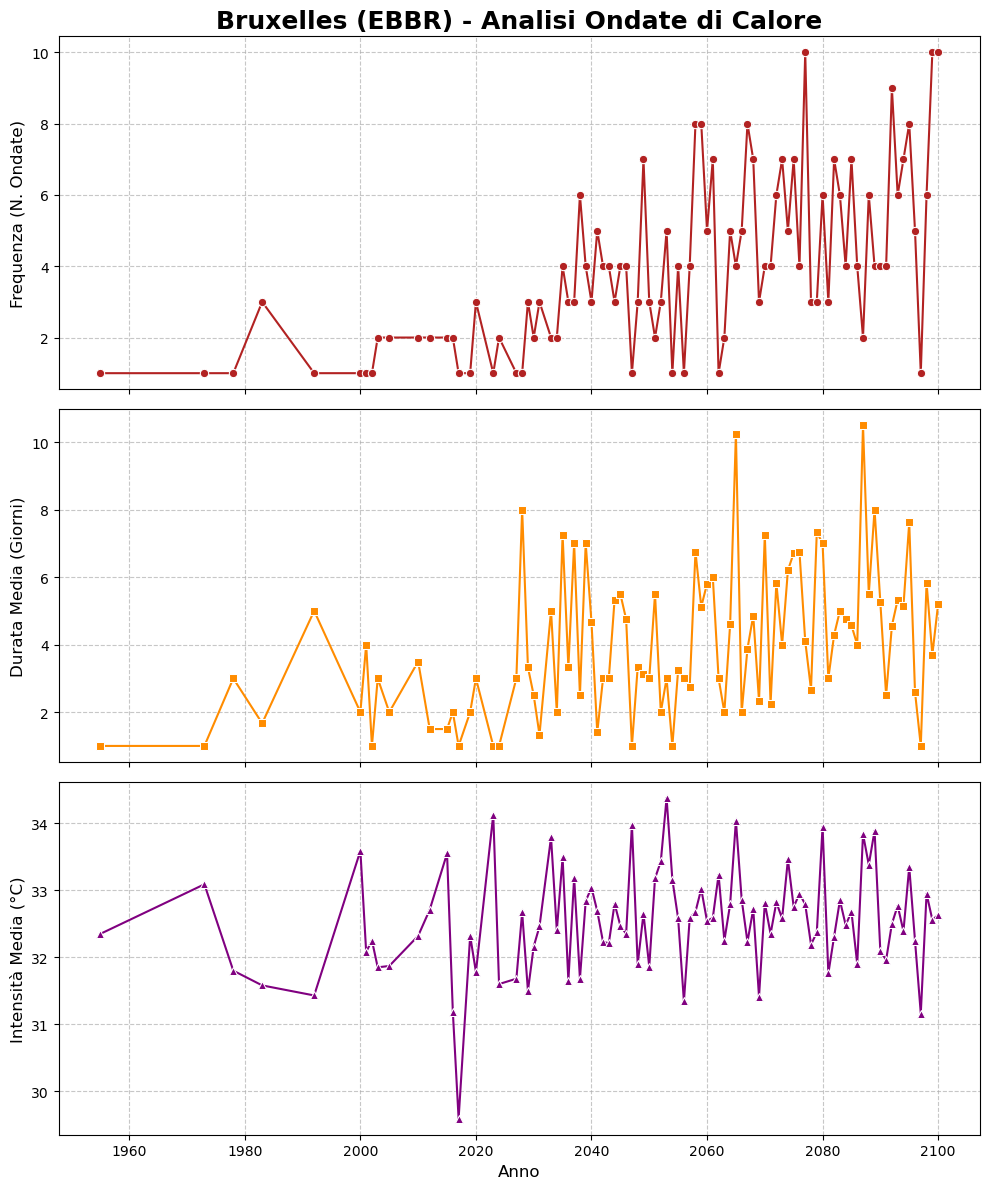

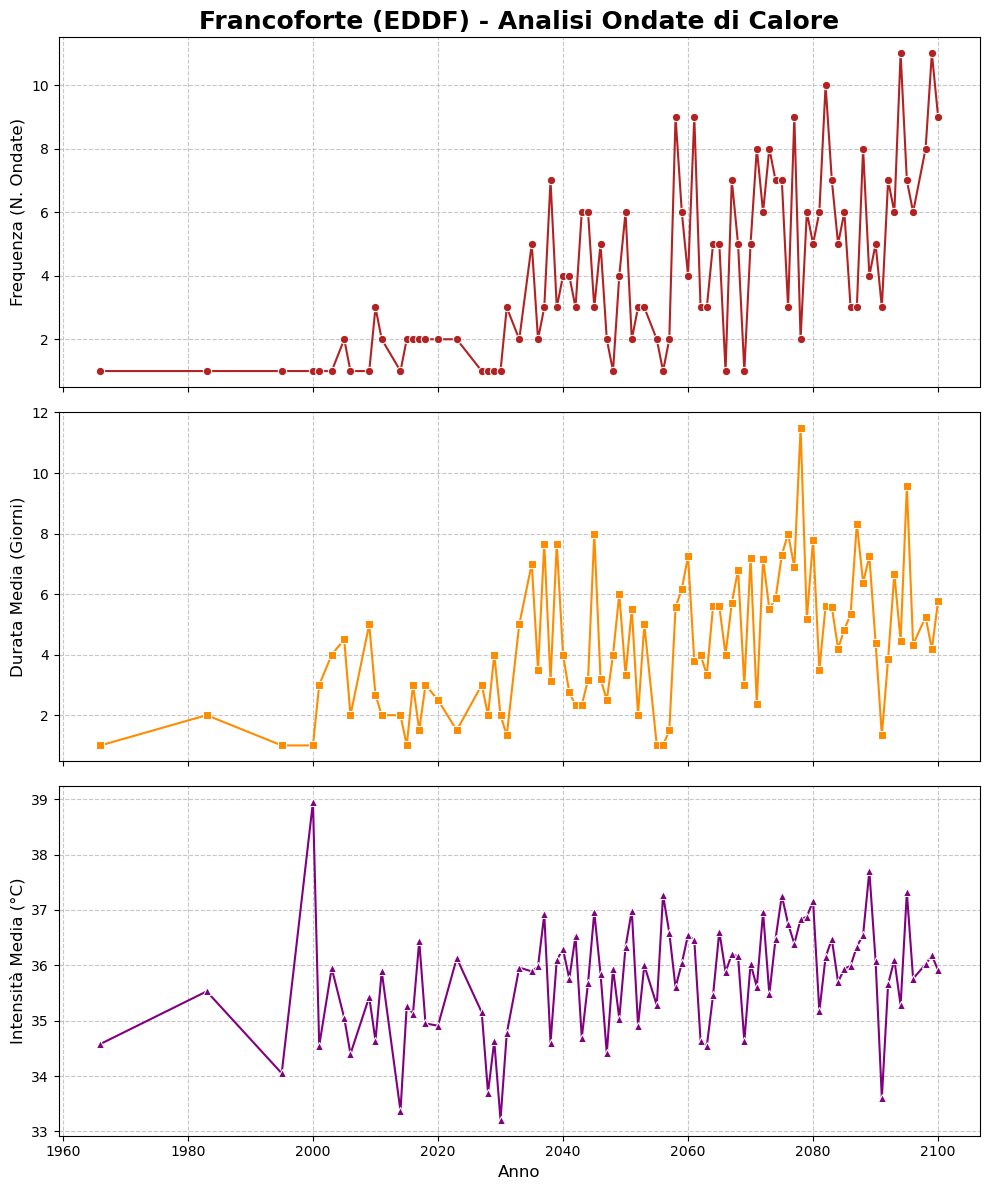

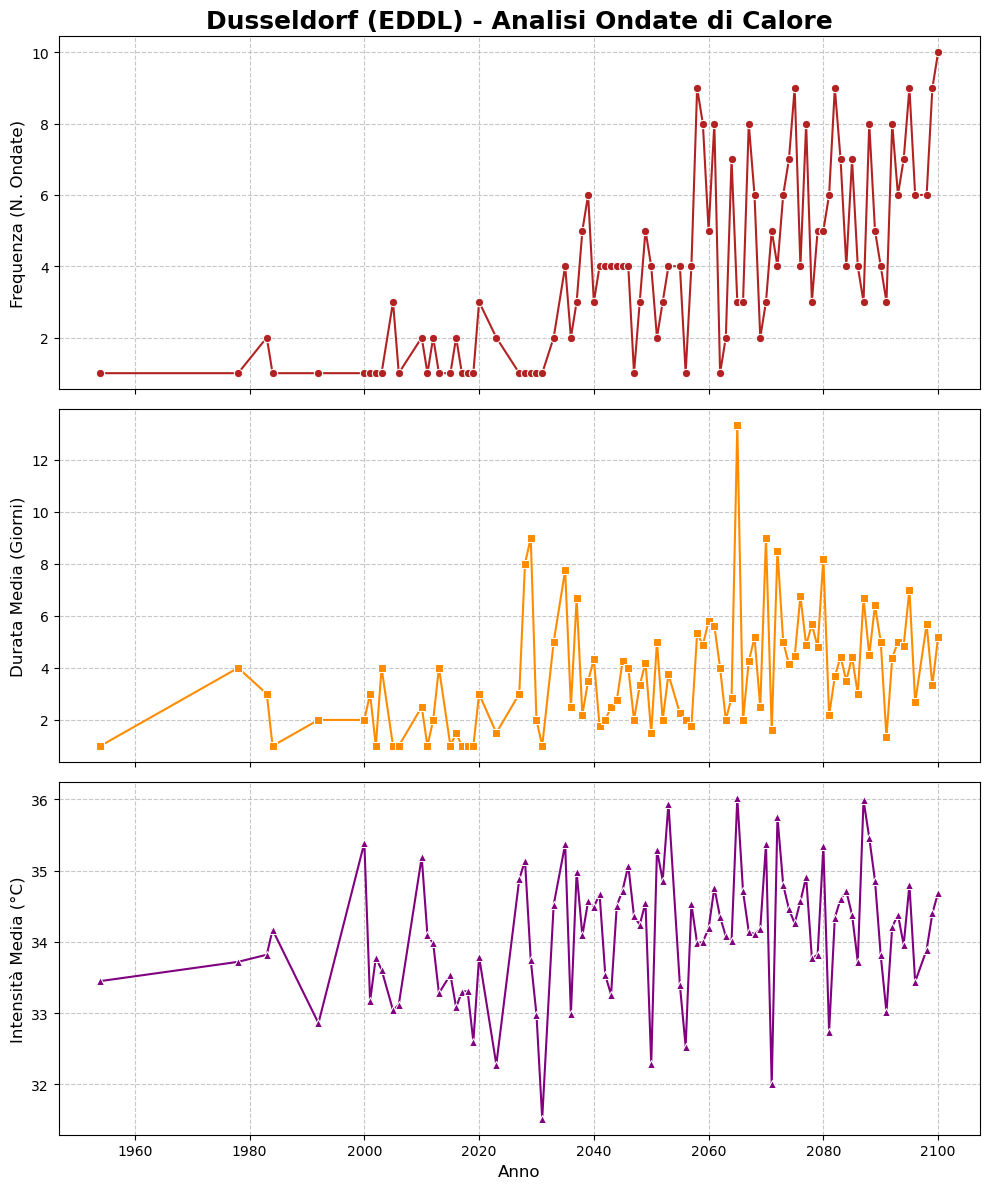

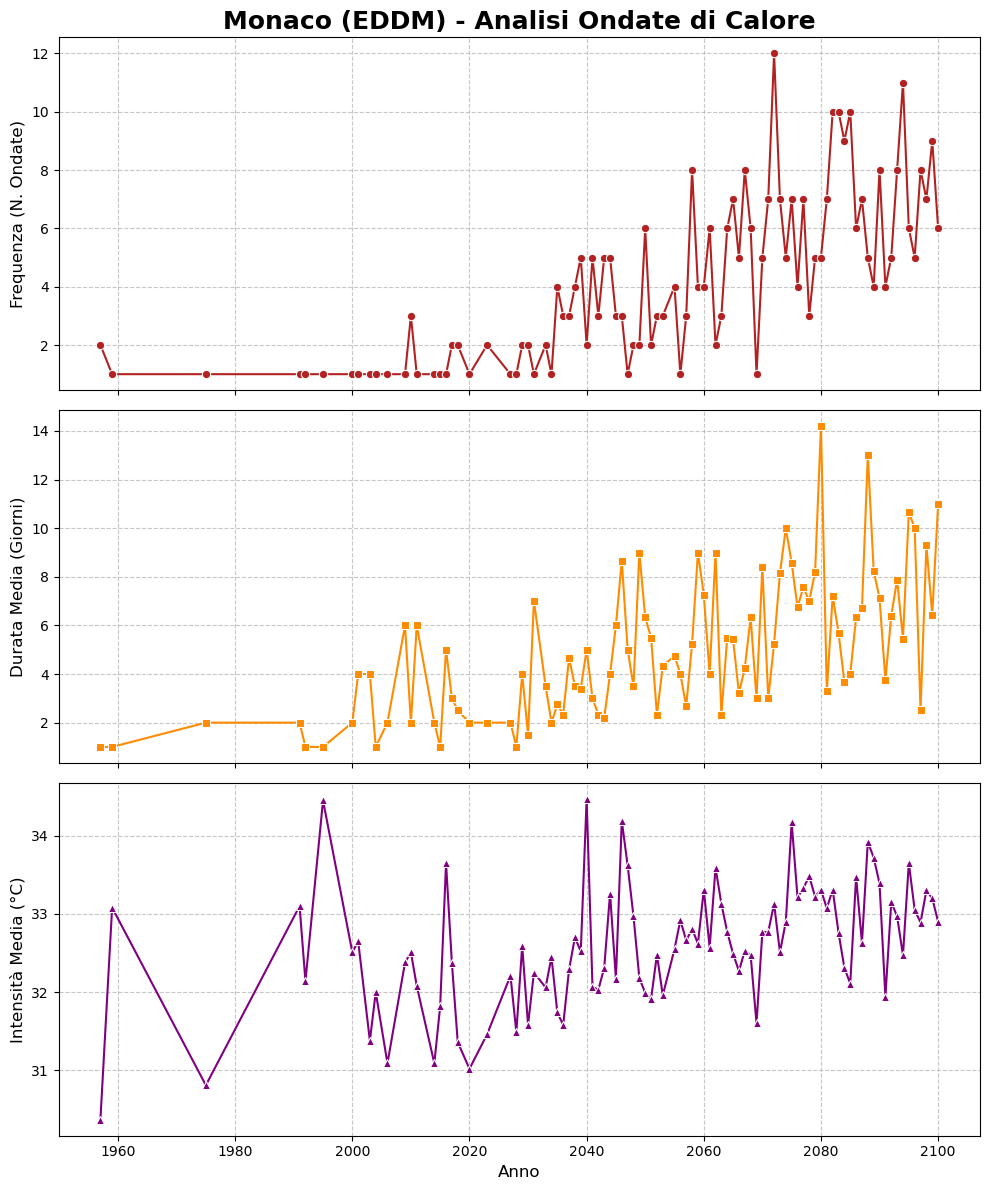

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carica il file (Pandas legge le virgole in automatico senza problemi!)
# Assicurati che il nome del file sia corretto e si trovi nella stessa cartella del notebook
file_csv = 'Risultati_HWI_Aprile_Ottobre_ACCESS-ESM1-5.csv'
df = pd.read_csv(file_csv)

# 2. Troviamo tutti gli aeroporti unici presenti nel file
aeroporti = df['Aeroporto'].unique()

# Dizionario delle città per gli aeroporti
airports_dict = {
    'EBBR': 'Bruxelles', 'EDDF': 'Francoforte', 'EDDL': 'Dusseldorf', 'EDDM': 'Monaco',
    'EGKK': 'Londra Gatwick', 'EGLC': 'Londra City', 'EGLL': 'Londra Heathrow', 'EHAM': 'Amsterdam',
    'EIDW': 'Dublino', 'EKCH': 'Copenaghen', 'ENGM': 'Oslo', 'ESSA': 'Stoccolma',
    'LEBL': 'Barcellona', 'LEMD': 'Madrid', 'LEPA': 'Palma di Maiorca', 'LESO': 'San Sebastian',
    'LFPG': 'Parigi CDG', 'LFPO': 'Parigi Orly', 'LGAV': 'Atene', 'LGHI': 'Chios',
    'LICG': 'Pantelleria', 'LIMC': 'Milano Malpensa', 'LIRF': 'Roma Fiumicino', 'LIRV': 'Roma Ciampino',
    'LOWW': 'Vienna', 'LPPT': 'Lisbona', 'LSZH': 'Zurigo', 'LTAI': 'Antalya',
    'LTFJ': 'Istanbul Sabiha', 'LTFM': 'Istanbul Ataturk',
    'KATL': 'Atlanta', 'KDFW': 'Dallas', 'KDEN': 'Denver', 'KORD': 'Chicago',
    'KLAX': 'Los Angeles', 'KJFK': 'New York JFK', 'KMCO': 'Orlando', 'KMIA': 'Miami',
    'KLAS': 'Las Vegas', 'KCLT': 'Charlotte', 'KSEA': 'Seattle', 'KSFO': 'San Francisco',
    'KPHX': 'Phoenix', 'KIAH': 'Houston', 'KBOS': 'Boston', 'KEWR': 'Newark',
    'KMSP': 'Minneapolis', 'KDTW': 'Detroit', 'KPHL': 'Philadelphia', 'KSLC': 'Salt Lake City',
    'KIAD': 'Washington', 'PANC': 'Anchorage', 'CYYZ': 'Toronto', 'CYVR': 'Vancouver',
    'CYUL': 'Montreal', 'CYYC': 'Calgary', 'CYHZ': 'Halifax', 'MMMX': 'Città del Messico',
    'MMUN': 'Cancun', 'MMGL': 'Guadalajara'
}
# Estraiamo solo i dati del futuro apocalittico (ssp585)
df_fut = df[df['Scenario'] == 'ssp585'].copy()

# Traduciamo le sigle nei nomi delle città usando il dizionario di prima
df_fut['Citta'] = df_fut['Aeroporto'].map(airports_dict)

print("🏆 PEGGIORI 5 AEROPORTI PER FREQUENZA (N. di ondate in un solo anno):")
print(df_fut.sort_values('Num_Ondate', ascending=False)[['Citta', 'Anno', 'Num_Ondate']].head(5).to_string(index=False))

print("\n🥵 PEGGIORI 5 AEROPORTI PER DURATA (Giorni consecutivi di ondata):")
print(df_fut.sort_values('Durata_Media_Giorni', ascending=False)[['Citta', 'Anno', 'Durata_Media_Giorni']].head(5).to_string(index=False))

print("\n🔥 PEGGIORI 5 AEROPORTI PER INTENSITÀ (°C medi durante l'ondata):")
print(df_fut.sort_values('Intensita_Media_K', ascending=False)[['Citta', 'Anno', 'Intensita_Media_K']].head(5).to_string(index=False))

# 3. Creiamo 3 grafici per ogni aeroporto!
for icao in aeroporti:
    # Filtriamo i dati solo per questo specifico aeroporto e ordiniamo per Anno
    df_apt = df[df['Aeroporto'] == icao].copy().sort_values('Anno')
    
    # Recuperiamo il nome della città
    nome_citta = airports_dict.get(icao, 'Sconosciuta')
    
    # Creiamo una figura con 3 "sotto-grafici" impilati verticalmente
    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
    
    # Grafico 1: FREQUENZA (Numero di Ondate)
    sns.lineplot(ax=axes[0], data=df_apt, x='Anno', y='Num_Ondate', marker='o', color='firebrick')
    axes[0].set_title(f'{nome_citta} ({icao}) - Analisi Ondate di Calore', fontsize=18, fontweight='bold')
    axes[0].set_ylabel('Frequenza (N. Ondate)', fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    # Grafico 2: DURATA (Giorni)
    sns.lineplot(ax=axes[1], data=df_apt, x='Anno', y='Durata_Media_Giorni', marker='s', color='darkorange')
    axes[1].set_ylabel('Durata Media (Giorni)', fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    # Grafico 3: INTENSITÀ (Temperature)
    sns.lineplot(ax=axes[2], data=df_apt, x='Anno', y='Intensita_Media_K', marker='^', color='purple')
    axes[2].set_ylabel('Intensità Media (°C)', fontsize=12)
    axes[2].set_xlabel('Anno', fontsize=12)
    axes[2].grid(True, linestyle='--', alpha=0.7)
    
    # Mostriamo il grafico completo e passiamo al prossimo aeroporto
    plt.tight_layout()
    plt.show()
